In [15]:
import pandas as pd
import numpy as np
import pydicom
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import os
import glob
import random

In [2]:
DICOM_BASE = "/mnt/cafetera/mammo/vindr/images"
ANNOTATIONS = "/home/enric_sena/Desktop/prova_enric/vindr_dataset/vindr/vindr/finding_annotations.csv"

In [8]:
annotations = pd.read_csv(ANNOTATIONS)
df=annotations # per practicitat més endavant
df.head()


,study_id,series_id,image_id,laterality,view_position,height,width,breast_birads,breast_density,finding_categories,finding_birads,xmin,ymin,xmax,ymax,split
0,48575a27b7c992427041a82fa750d3fa,26de4993fa6b8ae50a91c8baf49b92b0,4e3a578fe535ea4f5258d3f7f4419db8,R,CC,3518,2800,BI-RADS 4,DENSITY C,['Mass'],BI-RADS 4,2355.139893,1731.640015,2482.979980,1852.750000,training
1,48575a27b7c992427041a82fa750d3fa,26de4993fa6b8ae50a91c8baf49b92b0,dac39351b0f3a8c670b7f8dc88029364,R,MLO,3518,2800,BI-RADS 4,DENSITY C,['Mass'],BI-RADS 4,2386.679932,1240.609985,2501.800049,1354.040039,training
2,75e8e48933289d70b407379a564f8594,853b70e7e6f39133497909d9ca4c756d,c83f780904f25eacb44e9030f32c66e1,R,CC,3518,2800,BI-RADS 3,DENSITY C,['Global Asymmetry'],BI-RADS 3,2279.179932,1166.510010,2704.439941,2184.260010,training
3,75e8e48933289d70b407379a564f8594,853b70e7e6f39133497909d9ca4c756d,893528bc38a0362928a89364f1b692fd,R,MLO,3518,2800,BI-RADS 3,DENSITY C,['Global Asymmetry'],BI-RADS 3,1954.270020,1443.640015,2589.760010,2193.810059,training
4,c3487424fee1bdd4515b72dc3fd69813,77619c914263eae44e9099f1ce07192c,318264c881bf12f2c1efe5f93920cc37,R,CC,3518,2800,BI-RADS 4,DENSITY C,['Architectural Distortion'],BI-RADS 4,2172.300049,1967.410034,2388.699951,2147.159912,training


In [20]:
sample_images.head()

,study_id,image_id
1981,615242ea26bb1db9db5d74acd048d3cd,80782a78ce39bae561649b1d95df085b
1983,2dfe6025d5954c2925d6288b50dccbea,33ef0769c0bbda92028dd40d73a2bfae
521,f8ee167a08db61bba065976d89f2980c,3ca01aa63e24a7f0c873d0a939d1b003
1493,46ab23ec866810a4212c33db471153a2,52750d0cf16931d9f09530901041a345
2083,ec755916f14c0855c7c0a9a5e5c5cf4a,5f4d6a2a1c739c9a772f78f57e7825d6


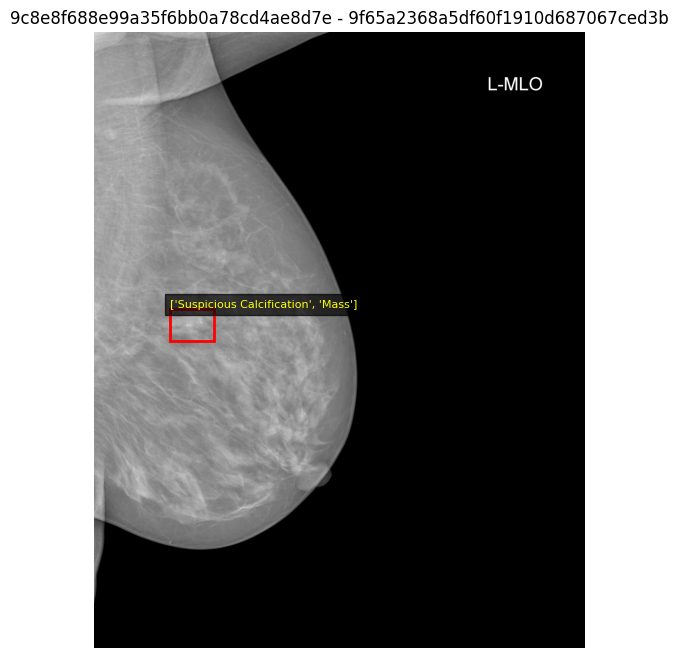

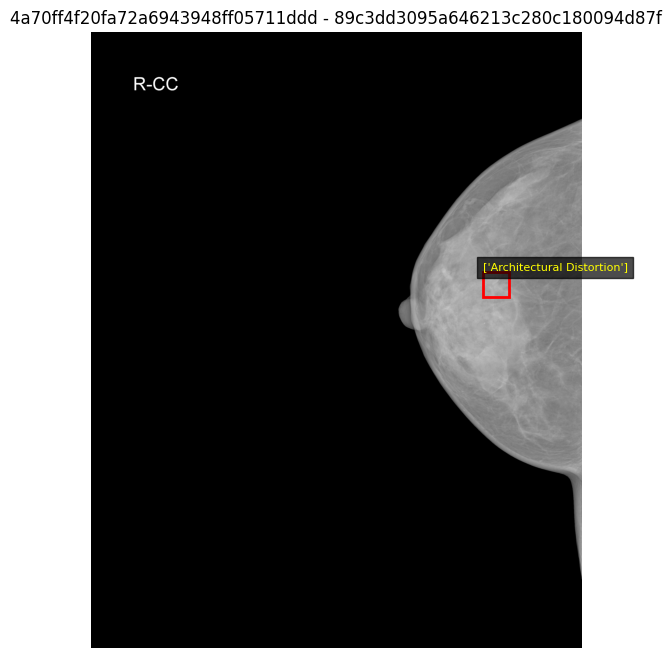

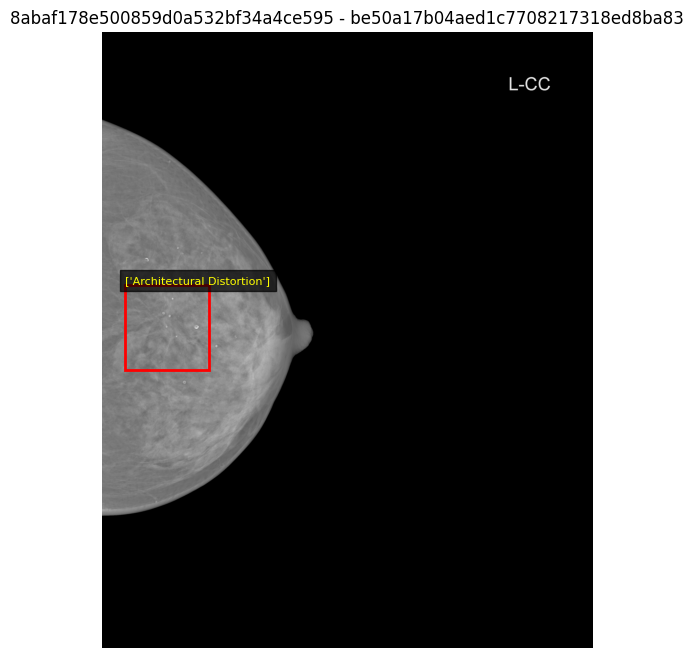

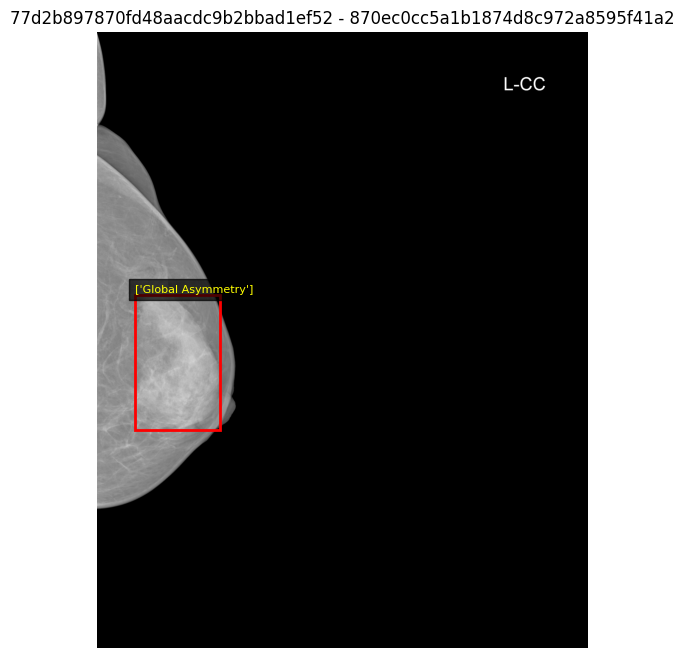

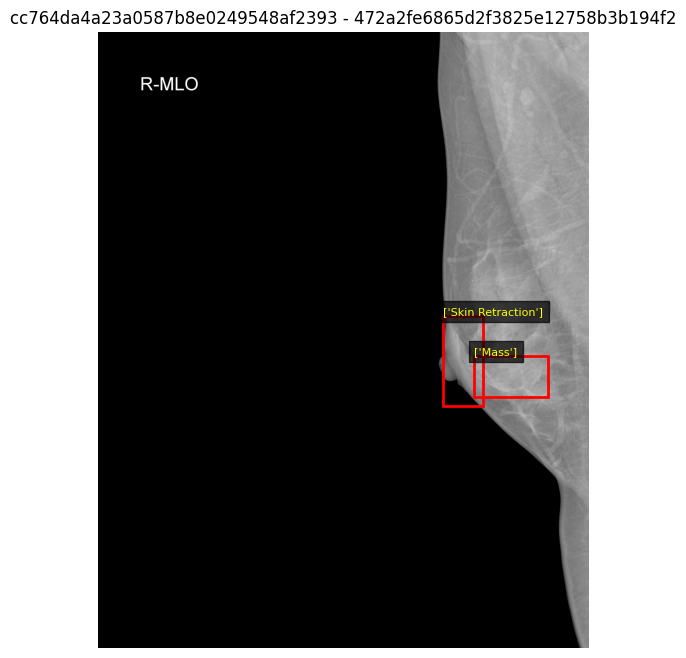

In [32]:
# Added lesion tags


sample_images = df[df["xmin"].notna()][['study_id','image_id']].drop_duplicates().sample(5,random_state=42)

for _, row in sample_images.iterrows():
    study_id = row['study_id']
    image_id = row['image_id']

    dicom_path = os.path.join(
        DICOM_BASE,
        study_id,
        f"{image_id}.dicom"
    )

    ds = pydicom.dcmread(dicom_path)
    image = ds.pixel_array

    annotations = df[
        (df['study_id'] == study_id) & 
        (df['image_id'] == image_id)
    ]

    fig, ax = plt.subplots(figsize=(8,8))
    ax.imshow(image, cmap="gray")

    for _, ann in annotations.iterrows():
        xmin = ann['xmin']
        xmax = ann['xmax']
        ymin = ann['ymin']
        ymax = ann['ymax']

        lesion = ann["finding_categories"] 

        rect = Rectangle(
            (xmin,ymin),
            xmax-xmin,
            ymax-ymin,
            fill=False,
            edgecolor='red',
            linewidth=2
        )

        ax.add_patch(rect)

        ax.text(
            xmin,
            ymin-10,
            lesion,
            color="yellow",
            fontsize=8,
            bbox=dict(facecolor="black", alpha=0.7)
        )

    ax.set_title(f'{study_id} - {image_id}')
    ax.axis('off')
    plt.show()

